# Glasma energy density

## Simulation parameters

In [1]:
import numpy as np

hbarc = 0.197326  # GeV * fm

su_group = 'su3'

# Lattice
L = 2       # fm
N = 512
tau_sim = 0.2   # fm/c
DTS = 8

# MV model
Qs = 2      # GeV
ns = 1
g = 2.0
mu = 0.5
ir = 0.2    # GeV
uv = 10.0   # GeV

# seed = 78456
# seed = 1996
seed = 7

# Dimensionless snapshot times g^2 mu tau — change here, then re-run sim + plot cells
tau_g2mu = [0.01, 0.5, 1.0]
# tau_g2mu = [0.01, 1.0]

## Set environment variables and import modules

In [2]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

import sys
sys.path.append('../..')

import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False
from curraun.energy import Energy
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

Using CUDA
Using SU(3)
Using double precision
Using double precision


## Evolve Glasma and record energy density snapshots

In [3]:
from tqdm import tqdm

a = L / N
E0 = N / L * hbarc
DT = 1.0 / DTS

# tau_g2mu is defined in the params cell
g2mu_fm     = g**2 * mu / hbarc          # 1/fm
tau_phys    = [td / g2mu_fm for td in tau_g2mu]    # fm/c
tau_lattice = [int(t / (a * DT)) for t in tau_phys]
n_steps     = max(tau_lattice)

# Initialize Glasma
mv.set_seed(seed)
s = core.Simulation(N, DT, g)
va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
initial.init(s, va, vb)

energy = Energy(s)
units = E0 ** 4 / hbarc ** 3   # GeV/fm^3

ed = [None] * len(tau_g2mu)
tau_map = {tl: i for i, tl in enumerate(tau_lattice)}

with tqdm(total=n_steps) as pbar:
    for t in range(1, n_steps + 1):
        core.evolve_leapfrog(s)
        if t in tau_map:
            energy.compute()
            el = energy.EL.reshape(N, N)
            bl = energy.BL.reshape(N, N)
            et = energy.ET.reshape(N, N)
            bt = energy.BT.reshape(N, N)
            ed[tau_map[t]] = (el + et + bl + bt) / t / g**2 * units
        pbar.update(1)

100%|██████████| 202/202 [01:08<00:00,  2.96it/s]


## Plot energy density at different times

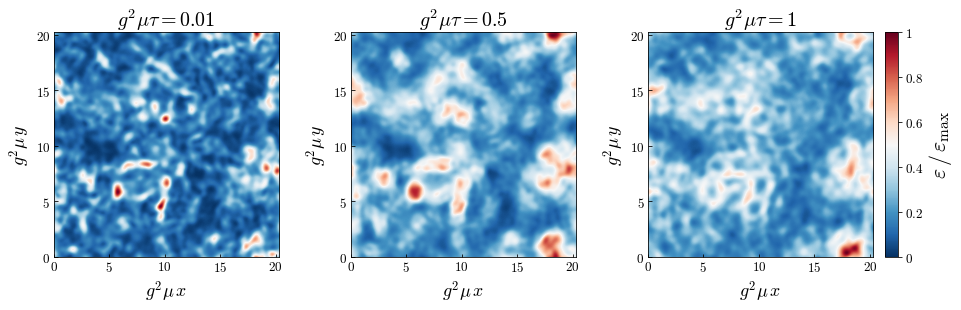

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator, FuncFormatter

rc('font', **{'family': 'serif', 'size': 14})
rc('mathtext', fontset='cm')

math_fmt = FuncFormatter(lambda x, pos: r'$%g$' % x)

g2mu   = g**2 * mu
g2mu4  = g2mu**4 / hbarc**3
ed_norm = [e / g2mu4 for e in ed]
ed_plot = [e / e.max() for e in ed_norm]

box  = g2mu_fm * L
half = box / 1

ncols  = len(tau_g2mu)
fs_bump = 2 if ncols == 2 else 0   # larger fonts for 2-col version
AXES_LABEL_FS = 18 + fs_bump
CBAR_LABEL_FS = 22 + fs_bump
TICK_FS       = 13 + fs_bump
TITLE_FS      = 20 + fs_bump

# 2-col: larger panels, tighter gap, bigger fonts
pw, ph   = (4.3, 4.5) if ncols >= 3 else (5.5, 5.5)
wspace   = 0.15 if ncols == 2 else 0.32
fig, ax = plt.subplots(1, ncols, figsize=(pw * ncols + 1.0, ph))
if ncols == 1:
    ax = [ax]

ims = []
for i, (eplot, td) in enumerate(zip(ed_plot, tau_g2mu)):
    im = ax[i].imshow(eplot, vmin=0.0, vmax=1.0, interpolation='bicubic',
                      cmap=plt.get_cmap('RdBu_r'), extent=[0, box, 0, box], origin='lower')
    ims.append(im)
    td_str = str(int(td)) if td == int(td) else str(td)
    ax[i].set_title(r'$g^2\mu\tau = ' + td_str + r'$', fontsize=TITLE_FS)
    ax[i].set_xlim(0, half)
    ax[i].set_ylim(0, half)
    ax[i].xaxis.set_major_locator(MultipleLocator(5))
    ax[i].yaxis.set_major_locator(MultipleLocator(5))
    ax[i].xaxis.set_major_formatter(math_fmt)
    ax[i].yaxis.set_major_formatter(math_fmt)
    ax[i].tick_params(which='both', direction='in', labelsize=TICK_FS)
    ax[i].set_xlabel(r'$g^2\mu\, x$', fontsize=AXES_LABEL_FS)
    ax[i].set_ylabel(r'$g^2\mu\, y$', fontsize=AXES_LABEL_FS)

plt.tight_layout()
plt.subplots_adjust(right=0.88, wspace=wspace)

pos = ax[-1].get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.013, pos.height])
cbar = fig.colorbar(ims[-1], cax=cbar_ax)
cbar.set_label(r'$\varepsilon\, /\, \varepsilon_{\rm max}$', fontsize=CBAR_LABEL_FS)
cbar.ax.yaxis.set_major_formatter(math_fmt)
cbar.ax.tick_params(labelsize=TICK_FS)

fig.savefig('glasma_energy_density_3.png', dpi=300, bbox_inches='tight')
fig.savefig('glasma_energy_density_3.pdf', bbox_inches='tight')

plt.show()


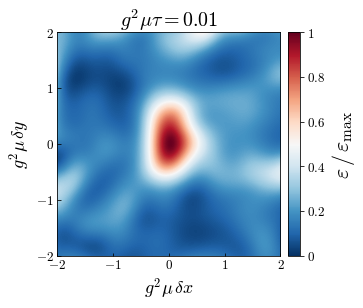

In [5]:
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator, FuncFormatter

rc('font', **{'family': 'serif', 'size': 14})
rc('mathtext', fontset='cm')

math_fmt = FuncFormatter(lambda x, pos: r'$%g$' % x)

# Earliest snapshot (tau_g2mu[0])
i_snap = 0
g2mu  = g**2 * mu
g2mu4 = g2mu**4 / hbarc**3
box   = g2mu_fm * L
e     = ed[i_snap] / g2mu4

# Location of peak energy density — becomes the coordinate origin
max_idx = np.unravel_index(e.argmax(), e.shape)
x_c = max_idx[1] * box / N   # g^2 mu * x_center
y_c = max_idx[0] * box / N   # g^2 mu * y_center

# Shift extent so (x_c, y_c) maps to (0, 0): extent = [dx_min, dx_max, dy_min, dy_max]
extent = [-x_c, box - x_c, -y_c, box - y_c]

delta = 2.0   # half-window in g^2 mu units

td_str = str(int(tau_g2mu[i_snap])) if tau_g2mu[i_snap] == int(tau_g2mu[i_snap]) else str(tau_g2mu[i_snap])

fig, ax = plt.subplots(figsize=(5, 4.5))

im = ax.imshow(e / e.max(), vmin=0.0, vmax=1.0, interpolation='bicubic',
               cmap=plt.get_cmap('RdBu_r'), extent=extent, origin='lower')

ax.set_xlim(-delta, delta)
ax.set_ylim(-delta, delta)
ax.set_title(r'$g^2\mu\tau = ' + td_str + r'$', fontsize=20)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_major_formatter(math_fmt)
ax.yaxis.set_major_formatter(math_fmt)
ax.tick_params(which='both', direction='in', labelsize=13)
ax.set_xlabel(r'$g^2\mu\,\delta x$', fontsize=18)
ax.set_ylabel(r'$g^2\mu\,\delta y$', fontsize=18)

plt.tight_layout()
plt.subplots_adjust(right=0.82)

pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.035, pos.height])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$\varepsilon\, /\, \varepsilon_{\rm max}$', fontsize=22)
cbar.ax.yaxis.set_major_formatter(math_fmt)
cbar.ax.tick_params(labelsize=13)

# fig.savefig('glasma_energy_density_zoom.png', dpi=300, bbox_inches='tight')
# fig.savefig('glasma_energy_density_zoom.pdf', bbox_inches='tight')

plt.show()

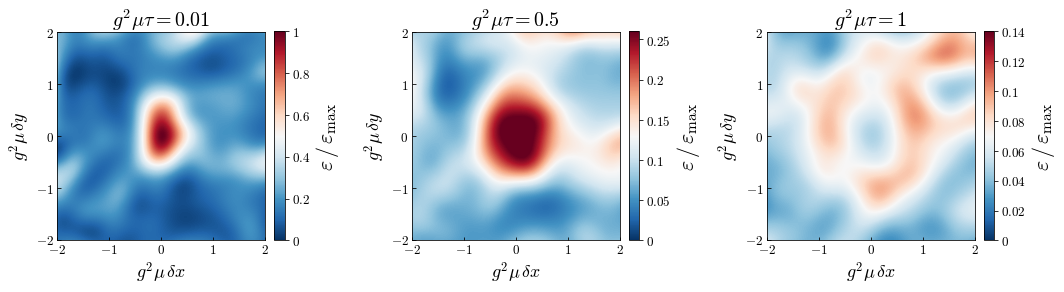

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator, FuncFormatter

rc('font', **{'family': 'serif', 'size': 14})
rc('mathtext', fontset='cm')

math_fmt = FuncFormatter(lambda x, pos: r'$%g$' % x)

g2mu   = g**2 * mu
g2mu4  = g2mu**4 / hbarc**3
box    = g2mu_fm * L
delta  = 2.0  # half-window in g^2 mu units

ncols  = len(tau_g2mu)
fs_bump = 2 if ncols == 2 else 0   # larger fonts for 2-col version
AXES_LABEL_FS = 18 + fs_bump
CBAR_LABEL_FS = 22 + fs_bump
TICK_FS       = 13 + fs_bump
TITLE_FS      = 20 + fs_bump

e_ref_max = (ed[0] / g2mu4).max()
max_idx   = np.unravel_index((ed[0] / g2mu4).argmax(), (N, N))

# vmax per panel in units of e_ref_max; None = use data max
_vmax_3 = [1.0, 0.26, 0.14]   # for 3-column layout
vmax_2  = [1.0, 0.15]          # for 2-column layout — adjust as needed

if ncols == 2:
    vmax_override = vmax_2 if len(vmax_2) == 2 else [None, None]
elif len(_vmax_3) == ncols:
    vmax_override = _vmax_3
else:
    vmax_override = [None] * ncols

# 2-col: larger panels, tighter gap, bigger fonts
pw, ph = (5.0, 4.5) if ncols >= 3 else (6.5, 5.5)
wspace = 0.35 if ncols == 2 else None   # None lets tight_layout decide
fig, ax = plt.subplots(1, ncols, figsize=(pw * ncols, ph))
if ncols == 1:
    ax = [ax]

for i, (e_raw, td) in enumerate(zip(ed, tau_g2mu)):
    e_norm    = e_raw / g2mu4 / e_ref_max
    e_centred = np.roll(np.roll(e_norm, N // 2 - max_idx[0], axis=0),
                                         N // 2 - max_idx[1], axis=1)
    vmax_i = vmax_override[i] if vmax_override[i] is not None else e_centred.max()

    extent = [-box / 2, box / 2, -box / 2, box / 2]
    td_str = str(int(td)) if td == int(td) else str(td)

    im = ax[i].imshow(e_centred, vmin=0.0, vmax=vmax_i, interpolation='bicubic',
                      cmap=plt.get_cmap('RdBu_r'), extent=extent, origin='lower')

    ax[i].set_xlim(-delta, delta)
    ax[i].set_ylim(-delta, delta)
    ax[i].set_title(r'$g^2\mu\tau = ' + td_str + r'$', fontsize=TITLE_FS)
    ax[i].xaxis.set_major_locator(MultipleLocator(1))
    ax[i].yaxis.set_major_locator(MultipleLocator(1))
    ax[i].xaxis.set_major_formatter(math_fmt)
    ax[i].yaxis.set_major_formatter(math_fmt)
    ax[i].tick_params(which='both', direction='in', labelsize=TICK_FS)
    ax[i].set_xlabel(r'$g^2\mu\,\delta x$', fontsize=AXES_LABEL_FS)
    ax[i].set_ylabel(r'$g^2\mu\,\delta y$', fontsize=AXES_LABEL_FS)

    cbar = plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)
    cbar.set_label(r'$\varepsilon\, /\, \varepsilon_{\rm max}$', fontsize=CBAR_LABEL_FS)
    cbar.ax.yaxis.set_major_formatter(math_fmt)
    cbar.ax.tick_params(labelsize=TICK_FS)

plt.tight_layout()
if wspace is not None:
    plt.subplots_adjust(wspace=wspace)

fig.savefig('glasma_energy_density_zoom_evolve_3.png', dpi=300, bbox_inches='tight')
fig.savefig('glasma_energy_density_zoom_evolve_3.pdf', bbox_inches='tight')

plt.show()
